**Drive mount + imports**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import os
import numpy as np

Mounted at /content/drive


**zip extract**

In [4]:
import zipfile

SOURCE_ZIP = '/content/drive/MyDrive/Thesis /Final /archive.zip'
DEST_PATH = '/content/data'

os.makedirs(DEST_PATH, exist_ok=True)
with zipfile.ZipFile(SOURCE_ZIP, 'r') as z:
    z.extractall(DEST_PATH)

print("Done.")

Done.


**DATA_PATH & split**

In [5]:
DATA_PATH = '/content/data/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
classes = ['Normal', 'Cyst', 'Tumor', 'Stone']

!pip install split-folders -q
import splitfolders

splitfolders.ratio(DATA_PATH, output="/content/split_data",
                    seed=42, ratio=(.7, .15, .15))

Copying files: 12446 files [00:14, 878.59 files/s] 


**dataset loaders**

In [6]:
IMG_SIZE = (224, 224)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/split_data/train', image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=42)
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/split_data/val', image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/split_data/test', image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 8710 files belonging to 4 classes.
Found 1865 files belonging to 4 classes.
Found 1871 files belonging to 4 classes.
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']


**augmentation + preprocessing**

In [7]:
from tensorflow.keras.applications.efficientnet import preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

**class weights**

In [8]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
for _, y in tf.keras.utils.image_dataset_from_directory(
        '/content/split_data/train', image_size=IMG_SIZE, batch_size=BATCH, shuffle=False):
    train_labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

Found 8710 files belonging to 4 classes.
{0: np.float64(0.8387904468412943), 1: np.float64(0.6128623698283141), 2: np.float64(2.2611630321910696), 3: np.float64(1.3626408010012516)}


**Cell — Model Define (title: ## Model: EfficientNetB0 (Transfer Learning)):**

In [9]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

**Cell — Training (title: ## Training with Class Weights):**

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 230s 709ms/step - accuracy: 0.6279 - loss: 0.9179 - val_accuracy: 0.5952 - val_loss: 0.8666
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 135s 495ms/step - accuracy: 0.7788 - loss: 0.6201 - val_accuracy: 0.6702 - val_loss: 0.7352
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 139s 483ms/step - accuracy: 0.8162 - loss: 0.5252 - val_accuracy: 0.6826 - val_loss: 0.7160
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 477ms/step - accuracy: 0.8307 - loss: 0.4822 - val_accuracy: 0.7228 - val_loss: 0.6373
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 131s 475ms/step - accuracy: 0.8476 - loss: 0.4398 - val_accuracy: 0.6740 - val_loss: 0.7501
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 134s 488ms/step - accuracy: 0.8498 - loss: 0.4267 - val_accuracy: 0.7475 - val_loss: 0.5848
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 129s 468ms/step - accuracy: 0.8587 - loss: 0.4005 - val_accuracy: 0.7389 - val_loss: 0.6159
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 132s 481ms/step - accuracy: 0.8595 -

**Cell — Training Curve Plot:**

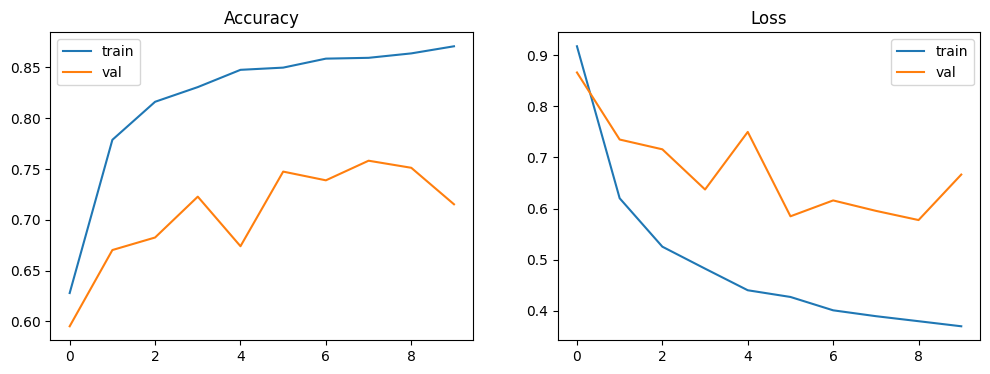

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()
plt.savefig('/content/training_curves_efficientnet.png', dpi=150)
plt.show()

**Cell — Test Evaluate + Classification Report:**

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

loss, acc = model.evaluate(test_ds)
print(f'Test accuracy: {acc:.4f}, Test loss: {loss:.4f}')

y_true, y_pred = [], []
for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 274ms/step - accuracy: 0.6905 - loss: 0.6842
Test accuracy: 0.6905, Test loss: 0.6842
              precision    recall  f1-score   support

        Cyst       0.81      0.93      0.86       557
      Normal       0.97      0.53      0.69       763
       Stone       0.30      0.85      0.44       208
       Tumor       0.88      0.57      0.69       343

    accuracy                           0.69      1871
   macro avg       0.74      0.72      0.67      1871
weighted avg       0.83      0.69      0.71      1871

[[517   0  40   0]
 [ 22 404 311  26]
 [ 27   5 176   0]
 [ 75   6  67 195]]


**Cell — Model Save:**

In [16]:
model.save('/content/drive/MyDrive/Thesis /Final /efficientnetb0_kidney_classweighted.keras')
print("Model saved!")

Model saved!


In [14]:
# Redefine a fresh EfficientNetB0 model (baseline, no class weights)
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = False

model_baseline = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model_baseline.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 178s 556ms/step - accuracy: 0.6940 - loss: 0.7993 - val_accuracy: 0.7072 - val_loss: 0.7158
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 132s 480ms/step - accuracy: 0.8080 - loss: 0.5325 - val_accuracy: 0.7094 - val_loss: 0.6797
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 130s 471ms/step - accuracy: 0.8369 - loss: 0.4550 - val_accuracy: 0.7330 - val_loss: 0.6362
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 156s 571ms/step - accuracy: 0.8510 - loss: 0.4136 - val_accuracy: 0.7678 - val_loss: 0.5536
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 158s 576ms/step - accuracy: 0.8691 - loss: 0.3814 - val_accuracy: 0.7802 - val_loss: 0.5451
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 133s 486ms/step - accuracy: 0.8721 - loss: 0.3634 - val_accuracy: 0.7437 - val_loss: 0.5852
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 477ms/step - accuracy: 0.8781 - loss: 0.3433 - val_accuracy: 0.7882 - val_loss: 0.5176
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 132s 482ms/step - accuracy: 0.8828 -

In [15]:
loss, acc = model_baseline.evaluate(test_ds)
print(f'Test accuracy: {acc:.4f}, Test loss: {loss:.4f}')

y_true, y_pred = [], []
for x, y in test_ds:
    preds = model_baseline.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.8177 - loss: 0.4585
Test accuracy: 0.8177, Test loss: 0.4585
              precision    recall  f1-score   support

        Cyst       0.75      0.99      0.86       557
      Normal       0.97      0.79      0.87       763
       Stone       0.57      0.68      0.62       208
       Tumor       0.88      0.68      0.77       343

    accuracy                           0.82      1871
   macro avg       0.79      0.79      0.78      1871
weighted avg       0.84      0.82      0.82      1871

[[554   0   3   0]
 [ 48 600  83  32]
 [ 59   7 142   0]
 [ 76  12  21 234]]


In [17]:
model.save('/content/drive/MyDrive/Thesis /Final /efficientnetb0_kidney_classweighted.keras')
print("Model saved!")

Model saved!
